In [67]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score 
from sklearn.naive_bayes import MultinomialNB, GaussianNB, CategoricalNB
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
data = pd.read_csv("../Datasets/training_df.csv")
data

,date,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,weather_code,...,soil_temperature_0_to_7cm,soil_temperature_7_to_28cm,soil_temperature_28_to_100cm,soil_temperature_100_to_255cm,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_moisture_28_to_100cm,soil_moisture_100_to_255cm,time,fire
0,2020-01-02 09:00:00+00:00,10.460000,95.428820,9.7600,9.326071,0.0,0.0,0.0,0.0,0.0,...,10.760000,13.110001,14.010000,21.910000,0.275,0.318,0.195,0.026,09:00:00,1
1,2020-01-02 09:00:00+00:00,10.453500,95.428590,9.7535,9.317741,0.0,0.0,0.0,0.0,0.0,...,10.753500,13.103500,14.003500,21.903500,0.275,0.318,0.195,0.026,09:00:00,1
2,2020-01-02 09:00:00+00:00,10.414500,95.427210,9.7145,9.267784,0.0,0.0,0.0,0.0,0.0,...,10.714500,13.064501,13.964500,21.864500,0.275,0.318,0.195,0.026,09:00:00,1
3,2020-01-02 09:00:00+00:00,9.223500,99.663920,9.1735,8.143780,0.0,0.0,0.0,0.0,0.0,...,10.423500,12.823500,13.723500,21.923500,0.273,0.324,0.201,0.020,09:00:00,1
4,2020-01-02 09:00:00+00:00,9.243000,99.663990,9.1930,8.168585,0.0,0.0,0.0,0.0,0.0,...,10.443000,12.842999,13.743000,21.942999,0.273,0.324,0.201,0.020,09:00:00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113891,2024-07-18 23:00:00+00:00,28.476500,26.921050,7.6265,26.616827,0.0,0.0,0.0,NaN,1.0,...,41.726498,30.776499,26.726500,18.426498,0.042,0.134,0.192,0.235,23:00:00,0
113892,2024-07-09 03:00:00+00:00,25.435000,36.749325,9.5850,24.854360,0.0,0.0,0.0,0.0,0.0,...,32.185000,28.734999,23.435000,17.535000,0.135,0.170,0.229,0.293,03:00:00,0
113893,2024-04-12 17:00:00+00:00,13.914001,82.397710,10.9640,13.423975,0.0,0.0,0.0,0.0,3.0,...,14.164001,13.364000,12.314000,12.314000,0.231,0.314,0.330,0.342,17:00:00,0
113894,2024-07-29 07:00:00+00:00,7.604000,52.525845,-1.4960,4.411881,0.0,0.0,0.0,NaN,0.0,...,10.654000,14.604001,13.604000,7.954000,0.270,0.296,0.347,0.392,07:00:00,0


In [69]:
data.fillna(0, inplace=True)
data.drop(['date', 'time'], axis=1, inplace=True)
data

,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,weather_code,pressure_msl,...,wind_gusts_10m,soil_temperature_0_to_7cm,soil_temperature_7_to_28cm,soil_temperature_28_to_100cm,soil_temperature_100_to_255cm,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_moisture_28_to_100cm,soil_moisture_100_to_255cm,fire
0,10.460000,95.428820,9.7600,9.326071,0.0,0.0,0.0,0.0,0.0,1012.4,...,11.879999,10.760000,13.110001,14.010000,21.910000,0.275,0.318,0.195,0.026,1
1,10.453500,95.428590,9.7535,9.317741,0.0,0.0,0.0,0.0,0.0,1012.4,...,11.879999,10.753500,13.103500,14.003500,21.903500,0.275,0.318,0.195,0.026,1
2,10.414500,95.427210,9.7145,9.267784,0.0,0.0,0.0,0.0,0.0,1012.4,...,11.879999,10.714500,13.064501,13.964500,21.864500,0.275,0.318,0.195,0.026,1
3,9.223500,99.663920,9.1735,8.143780,0.0,0.0,0.0,0.0,0.0,1012.5,...,13.320000,10.423500,12.823500,13.723500,21.923500,0.273,0.324,0.201,0.020,1
4,9.243000,99.663990,9.1930,8.168585,0.0,0.0,0.0,0.0,0.0,1012.5,...,13.320000,10.443000,12.842999,13.743000,21.942999,0.273,0.324,0.201,0.020,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113891,28.476500,26.921050,7.6265,26.616827,0.0,0.0,0.0,0.0,1.0,1015.9,...,38.160000,41.726498,30.776499,26.726500,18.426498,0.042,0.134,0.192,0.235,0
113892,25.435000,36.749325,9.5850,24.854360,0.0,0.0,0.0,0.0,0.0,1009.1,...,17.640000,32.185000,28.734999,23.435000,17.535000,0.135,0.170,0.229,0.293,0
113893,13.914001,82.397710,10.9640,13.423975,0.0,0.0,0.0,0.0,3.0,1012.1,...,18.720000,14.164001,13.364000,12.314000,12.314000,0.231,0.314,0.330,0.342,0
113894,7.604000,52.525845,-1.4960,4.411881,0.0,0.0,0.0,0.0,0.0,1017.0,...,18.720000,10.654000,14.604001,13.604000,7.954000,0.270,0.296,0.347,0.392,0


In [70]:
data.columns

Index(['temperature_2m', 'relative_humidity_2m', 'dew_point_2m',
       'apparent_temperature', 'precipitation', 'rain', 'snowfall',
       'snow_depth', 'weather_code', 'pressure_msl', 'surface_pressure',
       'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high',
       'et0_fao_evapotranspiration', 'vapour_pressure_deficit',
       'wind_speed_10m', 'wind_speed_100m', 'wind_direction_10m',
       'wind_direction_100m', 'wind_gusts_10m', 'soil_temperature_0_to_7cm',
       'soil_temperature_7_to_28cm', 'soil_temperature_28_to_100cm',
       'soil_temperature_100_to_255cm', 'soil_moisture_0_to_7cm',
       'soil_moisture_7_to_28cm', 'soil_moisture_28_to_100cm',
       'soil_moisture_100_to_255cm', 'fire'],
      dtype='object')

In [71]:
X = data.drop('fire', axis=1)
y = data['fire']

In [72]:
# Ensure all values are non-negative (MNB requires this)
assert (X >= 0).all().all(), "All features must be non-negative for MultinomialNB"


AssertionError: All features must be non-negative for MultinomialNB

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [74]:
print("Training Set shape:", X_train.shape)
print("Testing Set shape:", X_test.shape)


Training Set shape: (91116, 30)
Testing Set shape: (22780, 30)


In [75]:
from sklearn.preprocessing import MinMaxScaler

# Scale to non-negative values
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [54]:
pd.DataFrame(X_train_scaled).head().to_csv("../Datasets/sample_training_data_MultinomialNB.csv", index=False)

In [64]:
pd.DataFrame(X_train_scaled).head()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,0.561886,0.288645,0.666377,0.545238,0.0,0.0,0.0,0.0,0.0,0.395577,...,0.573244,0.195545,0.609468,0.647713,0.513636,0.515537,0.150495,0.188377,0.146341,0.308151
1,0.445056,0.203305,0.498846,0.409397,0.0,0.0,0.0,0.0,0.0,0.351351,...,0.731137,0.158416,0.391836,0.589781,0.499003,0.465675,0.009901,0.176353,0.304878,0.369781
2,0.395925,0.425737,0.614947,0.404208,0.0,0.0,0.0,0.0,0.0,0.373464,...,0.847004,0.240099,0.366666,0.424434,0.421429,0.361512,0.269307,0.302605,0.337398,0.524851
3,0.846176,0.256929,0.867713,0.830535,0.0,0.0,0.0,0.0,0.0,0.144963,...,0.377321,0.227723,0.866330,0.960624,0.960037,0.879079,0.035644,0.250501,0.069106,0.161034
4,0.203978,0.748570,0.571411,0.210899,0.0,0.0,0.0,0.0,0.0,0.616708,...,0.747335,0.301980,0.168580,0.283486,0.278793,0.401766,0.059406,0.304609,0.420732,0.409543


In [65]:
pd.DataFrame(X_train_scaled).head().to_csv("../Datasets/sample_testing_data_MultinomialNB.csv", index=False)

In [66]:
pd.DataFrame(X_test_scaled).head()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,0.570654,0.539709,0.821074,0.614850,0.0,0.0,0.0,0.0,0.000000,0.380835,...,0.675792,0.096535,0.492998,0.509582,0.513559,0.582031,0.261386,0.320641,0.443089,0.642147
1,0.444624,0.474826,0.681322,0.463302,0.0,0.0,0.0,0.0,0.000000,0.439803,...,0.315684,0.099010,0.357000,0.346245,0.545663,0.810524,0.376238,0.028056,0.006098,0.180915
2,0.515348,0.266461,0.611132,0.514278,0.0,0.0,0.0,0.0,0.013333,0.479115,...,0.365817,0.061881,0.421917,0.560721,0.531835,0.571408,0.259406,0.306613,0.436992,0.640159
3,0.636994,0.131347,0.558924,0.597635,0.0,0.0,0.0,0.0,0.013333,0.457002,...,0.555364,0.388614,0.553020,0.562831,0.584117,0.602974,0.150495,0.250501,0.292683,0.375746
4,0.631666,0.102083,0.506757,0.625410,0.0,0.0,0.0,0.0,0.000000,0.395577,...,0.143692,0.113861,0.588242,0.495411,0.484383,0.677427,0.079208,0.228457,0.268293,0.174950


### Multinomial Naive Bayes

In [76]:
mnb = MultinomialNB()
mnb.fit(X_train_scaled, y_train)

y_train_pred = mnb.predict(X_train_scaled)
y_test_pred = mnb.predict(X_test_scaled)


In [77]:
# Training accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.4f}")

# Testing accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Testing Accuracy: {test_accuracy:.4f}")


Training Accuracy: 0.5534
Testing Accuracy: 0.5550


Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.56      0.48      0.52     11258
           1       0.55      0.63      0.59     11522

    accuracy                           0.55     22780
   macro avg       0.56      0.55      0.55     22780
weighted avg       0.56      0.55      0.55     22780

Confusion Matrix on Test Set:
[[5384 5874]
 [4264 7258]]


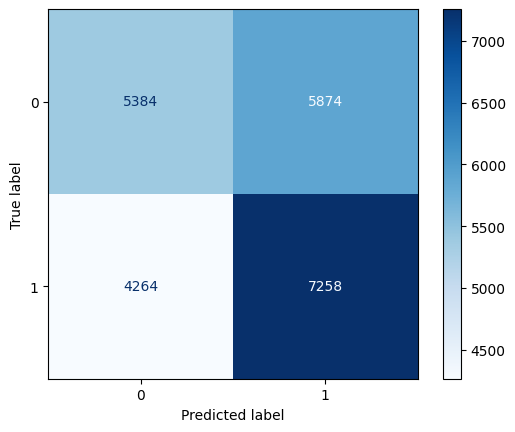

In [78]:
# Classification report
print("Classification Report on Test Set:")
print(classification_report(y_test, y_test_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix on Test Set:")
print(conf_matrix)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=mnb.classes_)
disp.plot(cmap='Blues')


AUC Score: 0.5812


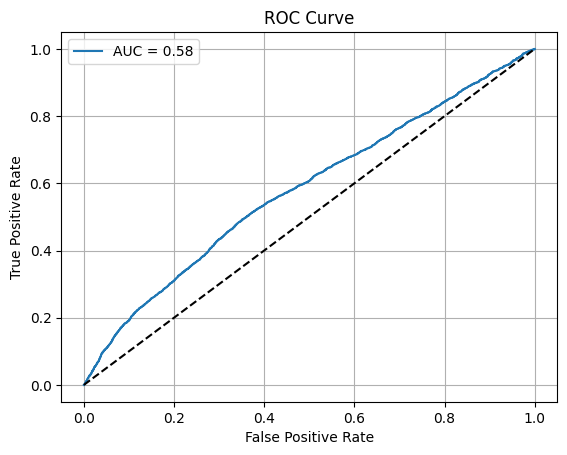

In [79]:
y_probs = mnb.predict_proba(X_test_scaled)[:, 1]  # Get probability estimates for class 1
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

print(f"AUC Score: {auc_score:.4f}")

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()


### Gaussian Naive Bayes

In [80]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [81]:
pd.DataFrame(X_train_scaled).head().to_csv("../Datasets/sample_training_data_GaussianNB.csv", index=False)

In [18]:
pd.DataFrame(X_train_scaled).head()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,0.511418,-0.402446,0.320015,0.403952,-0.050796,-0.050646,-0.00762,-0.022342,-0.127817,-0.362920,...,0.076309,0.337853,1.312226,0.942181,0.165759,-0.061828,-0.496839,-1.113534,-1.300906,-0.770100
1,-0.301463,-0.745139,-0.985358,-0.594069,-0.050796,-0.050646,-0.00762,-0.022342,-0.127817,-0.791550,...,0.621981,-0.026680,-0.121646,0.557944,0.057670,-0.399624,-1.383182,-1.200237,-0.403567,-0.446570
2,-0.643309,0.148061,-0.080720,-0.632190,-0.050796,-0.050646,-0.00762,-0.022342,-0.127817,-0.577235,...,1.022415,0.775293,-0.287477,-0.538725,-0.515342,-1.105291,0.252183,-0.289862,-0.219498,0.367473
3,2.489458,-0.529804,1.888784,2.500028,-0.050796,-0.050646,-0.00762,-0.022342,-0.127817,-2.791822,...,-0.600795,0.653782,3.004567,3.017574,3.463175,2.401025,-1.220894,-0.665572,-1.738071,-1.542397
4,-1.978839,1.444427,-0.419943,-2.052434,-0.050796,-0.050646,-0.00762,-0.022342,-0.127817,1.780228,...,0.677963,1.382848,-1.592573,-1.473567,-1.568948,-0.832584,-1.071090,-0.275412,0.252181,-0.237841


In [82]:
pd.DataFrame(X_train_scaled).head().to_csv("../Datasets/sample_testing_data_GaussianNB.csv", index=False)

In [19]:
pd.DataFrame(X_train_scaled).head()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,0.511418,-0.402446,0.320015,0.403952,-0.050796,-0.050646,-0.00762,-0.022342,-0.127817,-0.362920,...,0.076309,0.337853,1.312226,0.942181,0.165759,-0.061828,-0.496839,-1.113534,-1.300906,-0.770100
1,-0.301463,-0.745139,-0.985358,-0.594069,-0.050796,-0.050646,-0.00762,-0.022342,-0.127817,-0.791550,...,0.621981,-0.026680,-0.121646,0.557944,0.057670,-0.399624,-1.383182,-1.200237,-0.403567,-0.446570
2,-0.643309,0.148061,-0.080720,-0.632190,-0.050796,-0.050646,-0.00762,-0.022342,-0.127817,-0.577235,...,1.022415,0.775293,-0.287477,-0.538725,-0.515342,-1.105291,0.252183,-0.289862,-0.219498,0.367473
3,2.489458,-0.529804,1.888784,2.500028,-0.050796,-0.050646,-0.00762,-0.022342,-0.127817,-2.791822,...,-0.600795,0.653782,3.004567,3.017574,3.463175,2.401025,-1.220894,-0.665572,-1.738071,-1.542397
4,-1.978839,1.444427,-0.419943,-2.052434,-0.050796,-0.050646,-0.00762,-0.022342,-0.127817,1.780228,...,0.677963,1.382848,-1.592573,-1.473567,-1.568948,-0.832584,-1.071090,-0.275412,0.252181,-0.237841


In [83]:
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)


GaussianNB()

In [84]:
# Predictions
y_train_pred = gnb.predict(X_train_scaled)
y_test_pred = gnb.predict(X_test_scaled)


In [85]:
# Training accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.4f}")

# Testing accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Testing Accuracy: {test_accuracy:.4f}")


Training Accuracy: 0.5292
Testing Accuracy: 0.5338


Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.60      0.17      0.26     11258
           1       0.52      0.89      0.66     11522

    accuracy                           0.53     22780
   macro avg       0.56      0.53      0.46     22780
weighted avg       0.56      0.53      0.46     22780

Confusion Matrix on Test Set:
[[ 1897  9361]
 [ 1260 10262]]


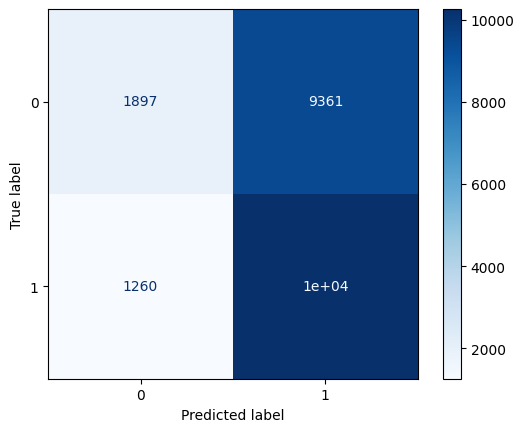

In [86]:
# Classification report
print("Classification Report on Test Set:")
print(classification_report(y_test, y_test_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix on Test Set:")
print(conf_matrix)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=mnb.classes_)
disp.plot(cmap='Blues')


AUC Score: 0.5832


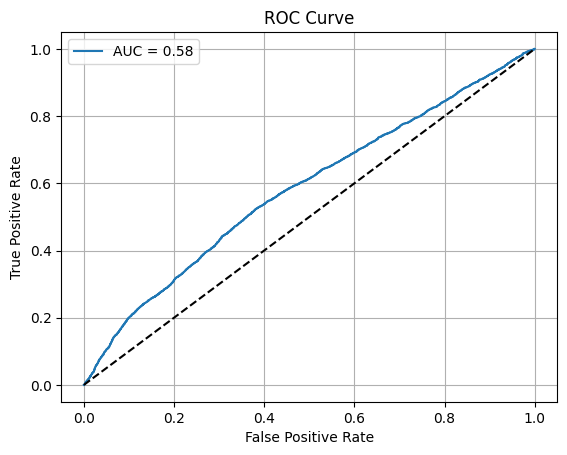

In [87]:
y_probs = mnb.predict_proba(X_test_scaled)[:, 1]  # Get probability estimates for class 1
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

print(f"AUC Score: {auc_score:.4f}")

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()


### Categorical Naïve Bayes

In [88]:
for bins in [3, 5, 7, 10]:
    binner = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy='uniform')
    X_train_binned = binner.fit_transform(X_train)
    X_test_binned = binner.transform(X_test)
    
    model = CategoricalNB()
    model.fit(X_train_binned, y_train)
    preds = model.predict(X_test_binned)
    acc = accuracy_score(y_test, preds)
    print(f"Bins: {bins}, Accuracy: {acc:.4f}")


Bins: 3, Accuracy: 0.5715
Bins: 5, Accuracy: 0.5741
Bins: 7, Accuracy: 0.5842
Bins: 10, Accuracy: 0.5839


In [89]:
# Bin continuous variables into categories
binner = KBinsDiscretizer(n_bins=7, encode='ordinal', strategy='uniform')
X_train_binned = binner.fit_transform(X_train)
X_test_binned = binner.transform(X_test)


In [90]:
pd.DataFrame(X_train_binned).head().to_csv("../Datasets/sample_training_data_CategoricalNB.csv", index=False)

In [27]:
pd.DataFrame(X_train_binned).head()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,3.0,2.0,4.0,3.0,0.0,0.0,0.0,0.0,0.0,2.0,...,4.0,1.0,4.0,4.0,3.0,3.0,1.0,1.0,1.0,2.0
1,3.0,1.0,3.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0,...,5.0,1.0,2.0,4.0,3.0,3.0,0.0,1.0,2.0,2.0
2,2.0,2.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0,...,5.0,1.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,3.0
3,5.0,1.0,6.0,5.0,0.0,0.0,0.0,0.0,0.0,1.0,...,2.0,1.0,6.0,6.0,6.0,6.0,0.0,1.0,0.0,1.0
4,1.0,5.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,4.0,...,5.0,2.0,1.0,1.0,1.0,2.0,0.0,2.0,2.0,2.0


In [91]:
pd.DataFrame(X_train_binned).head().to_csv("../Datasets/sample_testing_data_CategoricalNB.csv", index=False)

In [92]:
pd.DataFrame(X_test_binned).head()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,3.0,3.0,5.0,4.0,0.0,0.0,0.0,0.0,0.0,2.0,...,4.0,0.0,3.0,3.0,3.0,4.0,1.0,2.0,3.0,4.0
1,3.0,3.0,4.0,3.0,0.0,0.0,0.0,0.0,0.0,3.0,...,2.0,0.0,2.0,2.0,3.0,5.0,2.0,0.0,0.0,1.0
2,3.0,1.0,4.0,3.0,0.0,0.0,0.0,0.0,0.0,3.0,...,2.0,0.0,2.0,3.0,3.0,3.0,1.0,2.0,3.0,4.0
3,4.0,0.0,3.0,4.0,0.0,0.0,0.0,0.0,0.0,3.0,...,3.0,2.0,3.0,3.0,4.0,4.0,1.0,1.0,2.0,2.0
4,4.0,0.0,3.0,4.0,0.0,0.0,0.0,0.0,0.0,2.0,...,1.0,0.0,4.0,3.0,3.0,4.0,0.0,1.0,1.0,1.0


In [93]:
# Train CategoricalNB
cnb = CategoricalNB()
cnb.fit(X_train_binned, y_train)


CategoricalNB()

In [94]:
# Predictions
y_train_pred = cnb.predict(X_train_binned)
y_test_pred = cnb.predict(X_test_binned)


In [95]:
# Evaluation
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")


Training Accuracy: 0.5887
Testing Accuracy: 0.5842



Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.58      0.57      0.58     11258
           1       0.59      0.59      0.59     11522

    accuracy                           0.58     22780
   macro avg       0.58      0.58      0.58     22780
weighted avg       0.58      0.58      0.58     22780


Confusion Matrix on Test Set:
[[6459 4799]
 [4674 6848]]


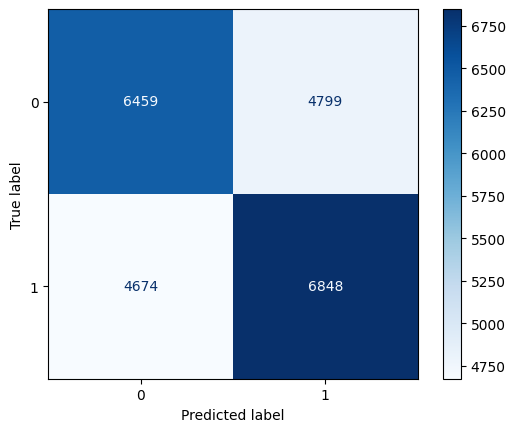

In [96]:
print("\nClassification Report on Test Set:")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix on Test Set:")
print(conf_matrix)

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=cnb.classes_)
disp.plot(cmap='Blues')


AUC Score: 0.6250


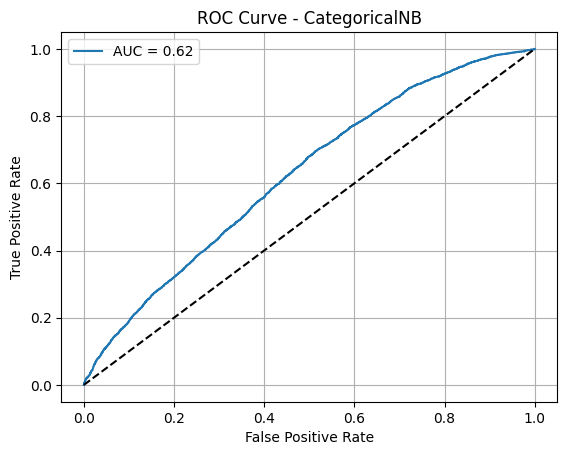

In [97]:
y_probs = cnb.predict_proba(X_test_binned)[:, 1]  # Get probability estimates for class 1
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

print(f"AUC Score: {auc_score:.4f}")

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - CategoricalNB')
plt.legend()
plt.grid()
plt.show()
